In [3]:
import os
import torch
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib import colormaps 
from scipy.integrate import solve_ivp
import timeit
from scipy.sparse import csr_array,block_array,eye,coo_array
import subprocess
import struct
from multiprocess import Pool
from IPython.display import Video,display
import networkx as nx
colors=plt.rcParams['axes.prop_cycle'].by_key()['color']

loadstr=''
try:
    loadstr='module load %s &&'%(subprocess.check_output("module avail | grep cuda/", shell=True, text=True).split()[-1])
except:
    pass

Define coupling parameters for CGLE

$$
\frac{\partial A}{\partial t} = A + (1+ib)\nabla^2 A - (1-ic)|A|^2 A,
$$

which we separate into real and imaginary parts $A=X+iY$ with


$$
\frac{\partial X}{\partial t} = X + \nabla^2 X - b \nabla^2 Y - (X^2+Y^2)X - c (X^2+Y^2)Y, 
$$

$$
\frac{\partial Y}{\partial t} = Y + \nabla^2 Y + b \nabla^2 X - (X^2+Y^2)Y + c (X^2+Y^2)X.
$$

We can find the indices for the coupling terms with the help function with no filebase. We illustrate first in two spatial dimensions and later in one and three spatial dimensions.

In [4]:
Ns=[256,256]
Ls=[100.0,100.0]
T=10
dt=0.1
cmd='%s ./rdcu -N %i,%i -L %f,%f -n 2 -h'%(loadstr, Ns[0],Ns[1],Ls[0],Ls[1])
print(cmd)
os.system(cmd)

module load cuda/12.9.1-binary && ./rdcu -N 256,256 -L 100.000000,100.000000 -n 2 -h
usage:	rdcu [-hvSFR] [-n NFIELDS] [-N NUMS] [-L LENGTHS]
	[-c COUPLING] [-A AMPLITUDE] [-t TIME] [-d DT] [-s SEED] 
	[-D DENSITY] [-g GPU] [-r RTOL] [-a ATOL]  FILEBASE 

-h for help. Call with -n and -N to see Y indices. 
-v for verbose output, including progress 
-S for stiff system. Use the BDF method with finite differences instead of RK45 pseudospectral method. 
-F for fixed timestep 
-R to reload final state from FILEBASEfs.dat if possible
NFIELDS is the number of fields. Default 1
NUMS is number of grid points in each dimension (up to three), separated by commas (no spaces). Default 128
LENGTHS is domain length in each dimension (up to three), separated by commas (no spaces). Default 1.0
COUPLING is a list of coupling terms, separated by commas (no spaces). Default empty
	The first value is the term coefficent. 
	The second value is an integer specifying the field that the term appears in. 
	The

0

In [5]:
filebase='data/2dcgle'

b=2.0 
c=0.8
couplings=['1.0,0,0,1', '1.0,0,6,1', '1.0,0,12,1', '-%f,0,7,1'%(b), \
           '-%f,0,13,1'%(b), '-1.0,0,0,3', '-1.0,0,0,1,1,2', '1.0,1,1,1', \
           '1.0,1,7,1', '1.0,1,13,1', '%f,1,6,1'%(b),'%f,1,12,1'%(b), \
           '-1.0,1,0,2,1,1', '-1.0,1,1,3', '%f,1,0,3'%(c), '%f,1,0,1,1,2'%(c), \
           '-%f,0,0,2,1,1'%(c),'-%f,0,1,3'%(c)]

file=open('%scoupling.dat'%(filebase),'w')
for line in couplings:
    print(line,file=file)
file.close()

Explicit runge-kutta pseudospectral on the gpu

In [21]:
cmd='%s ./rdcu -t %f -d %f -N %i,%i -L %f,%f -n 2 -v -D1 %s'%(loadstr,T,dt,Ns[0],Ns[1],Ls[0],Ls[1],filebase)
print(cmd)
os.system(cmd)

module load cuda/12.9.1-binary && ./rdcu -t 10.000000 -d 0.100000 -N 256,256 -L 100.000000,100.000000 -n 2 -v -D1 data/2dcgle
Using coupling terms from file
u0'=1.000(u0)^1 + 1.000(u0_00)^1 + 1.000(u0_11)^1 + -2.000(u1_00)^1 + -2.000(u1_11)^1 + -1.000(u0)^3 + -1.000(u0)^1(u1)^2 + -0.800(u0)^2(u1)^1 + -0.800(u1)^3 + 0
u1'=1.000(u1)^1 + 1.000(u1_00)^1 + 1.000(u1_11)^1 + 2.000(u0_00)^1 + 2.000(u0_11)^1 + -1.000(u0)^2(u1)^1 + -1.000(u1)^3 + 0.800(u0)^3 + 0.800(u0)^1(u1)^2 + 0
Using random initial conditions
1.000	3.211e+00	-2.973e-04	0.010712	924	
runtime: 3.212088


0

runtime: 3.212088



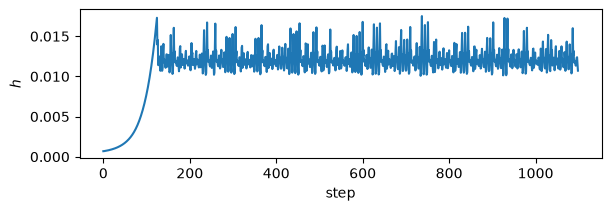

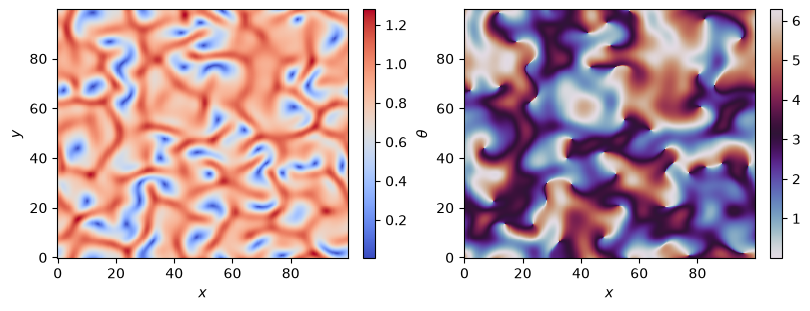

In [22]:
file=open(filebase+'.out')
print(file.readlines()[-1])
file.close()

ys=np.fromfile(filebase+'states.dat').reshape([-1]+[2]+Ns)
U0=ys[0].reshape(-1)
hs=np.fromfile(filebase+'steps.dat')

fig = plt.figure(figsize=(6,2),layout='constrained')
plt.plot(hs)
plt.xlabel(r'step')
plt.ylabel(r'$h$')
plt.show()


fig = plt.figure(figsize=(8,3), layout='constrained')
ax = fig.add_subplot(1,2,1)

R=(ys[-1][0]**2+ys[-1][1]**2)**0.5

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='coolwarm')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
plt.colorbar()

ax = fig.add_subplot(1,2,2)

R=np.atan2(ys[-1][1],ys[-1][0])+np.pi
plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='twilight')
ax.set_xlabel('$x$')
ax.set_ylabel(r'$\theta$')
plt.colorbar()

plt.show()


In [23]:
cmd='%s ./rdcu -t %f -d %f -N %i,%i -L %f,%f -n 2 -v -S -D1 -R %s'%(loadstr,2*T,dt,Ns[0],Ns[1],Ls[0],Ls[1],filebase)
print(cmd)
os.system(cmd)

module load cuda/12.9.1-binary && ./rdcu -t 20.000000 -d 0.100000 -N 256,256 -L 100.000000,100.000000 -n 2 -v -S -D1 -R data/2dcgle
Using coupling terms from file
u0'=1.000(u0)^1 + 1.000(u0_00)^1 + 1.000(u0_11)^1 + -2.000(u1_00)^1 + -2.000(u1_11)^1 + -1.000(u0)^3 + -1.000(u0)^1(u1)^2 + -0.800(u0)^2(u1)^1 + -0.800(u1)^3 + 0
u1'=1.000(u1)^1 + 1.000(u1_00)^1 + 1.000(u1_11)^1 + 2.000(u0_00)^1 + 2.000(u0_11)^1 + -1.000(u0)^2(u1)^1 + -1.000(u1)^3 + 0.800(u0)^3 + 0.800(u0)^1(u1)^2 + 0
Reloading final conditions from file
Couldn't read order!
Restarting at t=10.000927 with h=0.010712
1.003	3.641e+00	-1.143e-02	0.036304	286	
runtime: 3.645499


0

runtime: 3.645499



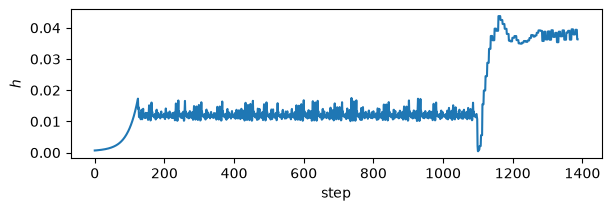

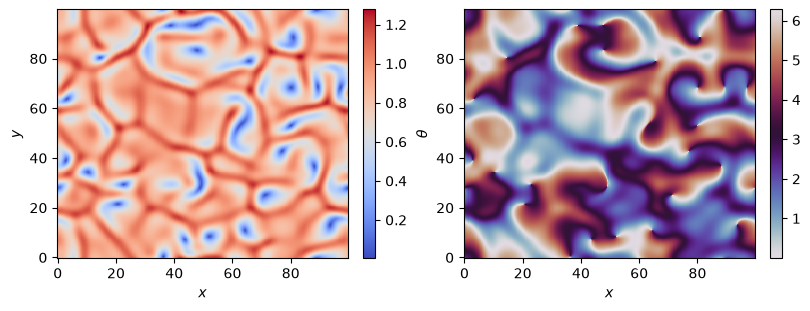

In [25]:
file=open(filebase+'.out')
print(file.readlines()[-1])
file.close()

ys=np.fromfile(filebase+'states.dat').reshape([-1]+[2]+Ns)
U0=ys[0].reshape(-1)
ts=np.fromfile(filebase+'times.dat')
hs=np.fromfile(filebase+'steps.dat')

fig = plt.figure(figsize=(6,2),layout='constrained')
plt.plot(hs)
plt.xlabel(r'step')
plt.ylabel(r'$h$')
plt.show()


fig = plt.figure(figsize=(8,3), layout='constrained')
ax = fig.add_subplot(1,2,1)

R=(ys[-1][0]**2+ys[-1][1]**2)**0.5

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='coolwarm')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
plt.colorbar()

ax = fig.add_subplot(1,2,2)

R=np.atan2(ys[-1][1],ys[-1][0])+np.pi
plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='twilight')
ax.set_xlabel('$x$')
ax.set_ylabel(r'$\theta$')
plt.colorbar()

plt.show()


In [20]:
hs[:5]

array([0.00214248, 0.00045955, 0.00045955, 0.00098338, 0.00098338])

implicit BDF with finite differences on gpu with the same initial condition. Note the first few timesteps are small before the BDF stabilizes.

In [7]:
cmd='%s ./rdcu -t %f -d %f -N %i,%i -L %f,%f -n 2 -v -S -D1 %s'%(loadstr,T,dt,Ns[0],Ns[1],Ls[0],Ls[1],filebase)

print(cmd)
os.system(cmd)

module load cuda/12.9.1-binary && ./rdcu -t 10.000000 -d 0.100000 -N 256,256 -L 100.000000,100.000000 -n 2 -v -S -D1 data/2dcgle
Using coupling terms from file
u0'=1.000(u0)^1 + 1.000(u0_00)^1 + 1.000(u0_11)^1 + -2.000(u1_00)^1 + -2.000(u1_11)^1 + -1.000(u0)^3 + -1.000(u0)^1(u1)^2 + -0.800(u0)^2(u1)^1 + -0.800(u1)^3 + 0
u1'=1.000(u1)^1 + 1.000(u1_00)^1 + 1.000(u1_11)^1 + 2.000(u0_00)^1 + 2.000(u0_11)^1 + -1.000(u0)^2(u1)^1 + -1.000(u1)^3 + 0.800(u0)^3 + 0.800(u0)^1(u1)^2 + 0
Using random initial conditions
1.002	5.415e+00	-1.209e-02	0.035750	629	
runtime: 5.427071


0

runtime: 5.427071



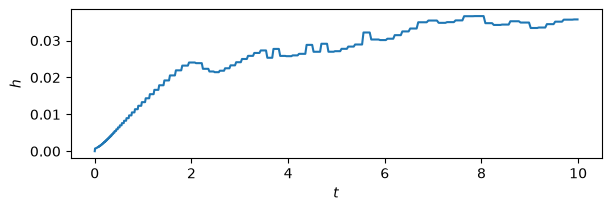

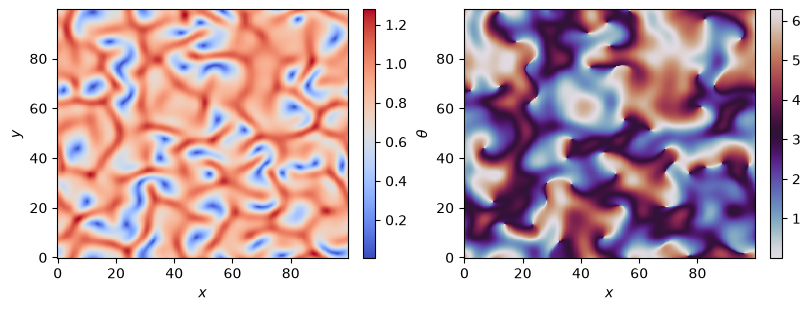

In [8]:
file=open(filebase+'.out')
print(file.readlines()[-1])
file.close()

ys=np.fromfile(filebase+'states.dat').reshape([-1]+[2]+Ns)
ts=np.fromfile(filebase+'times.dat')

fig = plt.figure(figsize=(6,2),layout='constrained')
plt.plot(ts[:-1],np.diff(ts))
plt.xlabel(r'$t$')
plt.ylabel(r'$h$')
plt.show()


fig = plt.figure(figsize=(8,3), layout='constrained')
ax = fig.add_subplot(1,2,1)

R=(ys[-1][0]**2+ys[-1][1]**2)**0.5

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='coolwarm')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
plt.colorbar()

ax = fig.add_subplot(1,2,2)

R=np.atan2(ys[-1][1],ys[-1][0])+np.pi

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='twilight')
ax.set_xlabel('$x$')
ax.set_ylabel(r'$\theta$')
plt.colorbar()

plt.show()


Explicit runge-kutta pseudospectral on the cpu. The GPU results are almost identical and much faster, and performance benefits increase with increasing Ns.

In [9]:
def lap(y,Ls,Ns):
    yfft=np.fft.fftn(y)
    ret=-np.fft.fftfreq(Ns[0],Ls[0]/(2*np.pi*Ns[0])).reshape((Ns[0],1))**2*yfft
    ret=ret-np.fft.fftfreq(Ns[1],Ls[1]/(2*np.pi*Ns[1])).reshape((1,Ns[1]))**2*yfft
    return np.fft.ifftn(ret)

def cgle(t, U, b, c, Ls, Ns):
    N=Ns[0]*Ns[1]
    X=U[:N].reshape(Ns)
    Y=U[N:].reshape(Ns)
    A=X+1j*Y
    lapA=lap(A,Ls,Ns)
    lapX=np.real(lapA)
    lapY=np.imag(lapA)
    retX=X+lapX-b*lapY-(X**2+Y**2)*(X+c*Y)
    retY=Y+lapY+b*lapX-(X**2+Y**2)*(Y-c*X)
    ret=np.zeros(U.shape)
    ret[:N]=retX.reshape(-1)
    ret[N:]=retY.reshape(-1)
    return ret

start=timeit.default_timer()
sol1=solve_ivp(cgle,[0,T],U0,args=[b,c,Ls,Ns],method='RK45',rtol=1E-8,atol=1E-8,first_step=0.03)
stop=timeit.default_timer()
print("runtime: ", stop-start, flush=True)

ys=sol1.y.reshape([2]+Ns+[-1]).transpose(3,0,1,2)
ts=sol1.t

runtime:  16.543152207974344


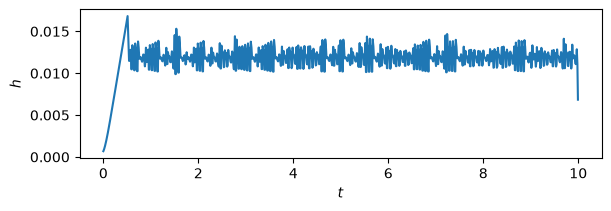

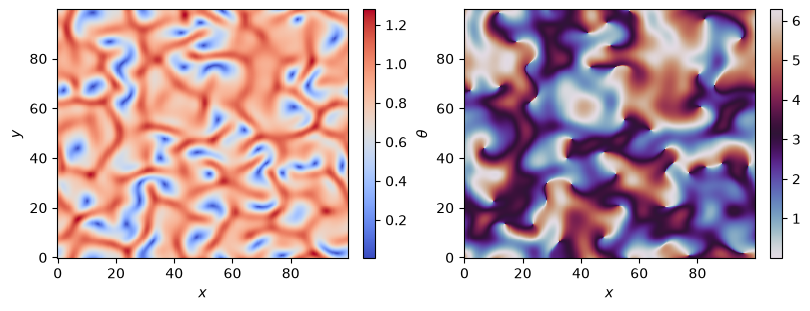

In [10]:
ys=sol1.y.reshape([2]+Ns+[-1]).transpose(3,0,1,2)
ts=sol1.t

fig = plt.figure(figsize=(6,2),layout='constrained')
plt.plot(ts[:-1],np.diff(ts))
plt.xlabel(r'$t$')
plt.ylabel(r'$h$')
plt.show()


fig = plt.figure(figsize=(8,3), layout='constrained')
ax = fig.add_subplot(1,2,1)

R=(ys[-1][0]**2+ys[-1][1]**2)**0.5

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='coolwarm')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
plt.colorbar()

ax = fig.add_subplot(1,2,2)

R=np.atan2(ys[-1][1],ys[-1][0])+np.pi

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='twilight')
ax.set_xlabel('$x$')
ax.set_ylabel(r'$\theta$')
plt.colorbar()

plt.show()


implicit BDF with finite differences on cpu. The GPU results are again almost identical and are comparatively even faster. The sparse LU solver from scipy performs poorly compared to cudss and scales very poorly with increasing Ns.

In [11]:
def lap(y,Ls,Ns):
    return (np.roll(y,1,axis=0)+np.roll(y,-1,axis=0)-2*y)/(Ls[0]/Ns[0])**2+(np.roll(y,1,axis=1)+np.roll(y,-1,axis=1)-2*y)/(Ls[1]/Ns[1])**2

def cgle(t, U, b, c, Ls, Ns, I, JI):
    N=Ns[0]*Ns[1]
    X=U[:N].reshape(Ns)
    Y=U[N:].reshape(Ns)
    A=X+1j*Y
    lapA=lap(A,Ls,Ns)
    lapX=np.real(lapA)
    lapY=np.imag(lapA)
    retX=X+lapX-b*lapY-(X**2+Y**2)*(X+c*Y)
    retY=Y+lapY+b*lapX-(X**2+Y**2)*(Y-c*X)
    ret=np.zeros(U.shape)
    ret[:N]=retX.reshape(-1)
    ret[N:]=retY.reshape(-1)
    return ret

def jac(t, U, b, c, Ls, Ns, I, JI):
    N=Ns[0]*Ns[1]
    X=U[:N]
    Y=U[N:]
#     retX=X+lapX-b*lapY-(X**2+Y**2)*(X+c*Y)
    retXX=I+JI-(2*X*I)*(X+c*Y)-(X**2+Y**2)*I
    retXY=-b*JI-(2*Y*I)*(X+c*Y)-(X**2+Y**2)*I*c
#     retY=Y+lapY+b*lapX-(X**2+Y**2)*(Y-c*X)
    retYX=b*JI-(2*X*I)*(Y-c*X)+(X**2+Y**2)*I*c
    retYY=I+JI-(2*Y*I)*(Y-c*X)-(X**2+Y**2)*I
    return block_array([[retXX,retYX],[retXY, retYY]]).T

N=Ns[0]*Ns[1]
I=csr_array(eye(N))
coords=I.reshape(Ns+Ns).coords
data=I.reshape(Ns+Ns).data
Ip0=coo_array((data,(coords[0],coords[1],np.roll(coords[2],Ns[0]),coords[3])),Ns+Ns).reshape(N,N)
Ip1=coo_array((data,(coords[0],coords[1],coords[2],np.roll(coords[3],1))),Ns+Ns).reshape(N,N)
Im0=coo_array((data,(coords[0],coords[1],np.roll(coords[2],-Ns[0]),coords[3])),Ns+Ns).reshape(N,N)
Im1=coo_array((data,(coords[0],coords[1],coords[2],np.roll(coords[3],-1))),Ns+Ns).reshape(N,N)
JI=(Ip0+Im0-2*I)/(Ls[0]/Ns[0])**2+(Ip1+Im1-2*I)/(Ls[1]/Ns[1])**2

start=timeit.default_timer()
sol2=solve_ivp(cgle,[0,T],U0,args=[b,c,Ls,Ns,I,JI],method='BDF',jac=jac,rtol=1E-8,atol=1E-8)
stop=timeit.default_timer()
print("runtime: ", stop-start, flush=True)

runtime:  771.7922365100821


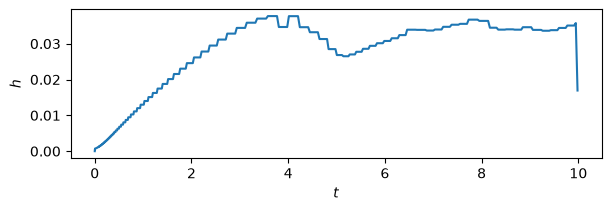

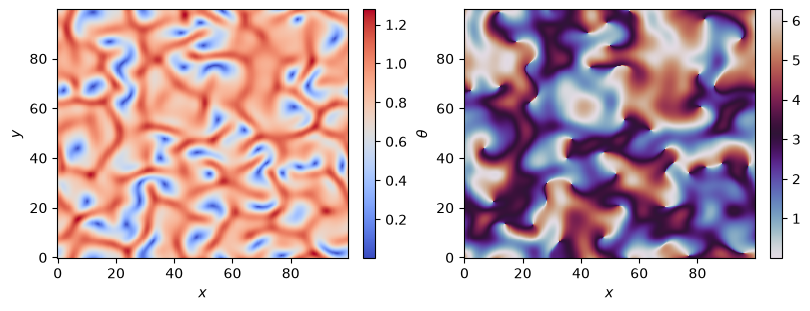

In [11]:
ys=sol2.y.reshape([2]+Ns+[-1]).transpose(3,0,1,2)
ts=sol2.t

fig = plt.figure(figsize=(6,2),layout='constrained')
plt.plot(ts[:-1],np.diff(ts))
plt.xlabel(r'$t$')
plt.ylabel(r'$h$')
plt.show()


fig = plt.figure(figsize=(8,3), layout='constrained')
ax = fig.add_subplot(1,2,1)

R=(ys[-1][0]**2+ys[-1][1]**2)**0.5

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='coolwarm')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
plt.colorbar()

ax = fig.add_subplot(1,2,2)

R=np.atan2(ys[-1][1],ys[-1][0])+np.pi

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='twilight')
ax.set_xlabel('$x$')
ax.set_ylabel(r'$\theta$')
plt.colorbar()

plt.show()


Note that BDF takes larger steps that RK45. As the number of mesh points Ns increases, the system gets stiffer and RK45 takes increasingly smaller steps while BDF does not. The sparse LU scales well enough that BDF outperforms RK45 for large Ns.  Even though the pseudospectral discretization is generally superior to finite difference, BDF may be preferred for fine spatial resolution. Illustrate with a large system size.

In [12]:
Ns=[1024,1024]
Ls=[100.0,100.0]

cmd='%s ./rdcu -t %f -d %f -N %i,%i -L %f,%f -n 2 -v -D1 %s'%(loadstr,T,dt,Ns[0],Ns[1],Ls[0],Ls[1],filebase)
print(cmd)
os.system(cmd)

module load cuda/12.9.1-binary && ./rdcu -t 10.000000 -d 0.100000 -N 1024,1024 -L 100.000000,100.000000 -n 2 -v -D1 data/2dcgle
Using coupling terms from file
u0'=1.000(u0)^1 + 1.000(u0_00)^1 + 1.000(u0_11)^1 + -2.000(u1_00)^1 + -2.000(u1_11)^1 + -1.000(u0)^3 + -1.000(u0)^1(u1)^2 + -0.800(u0)^2(u1)^1 + -0.800(u1)^3 + 0
u1'=1.000(u1)^1 + 1.000(u1_00)^1 + 1.000(u1_11)^1 + 2.000(u0_00)^1 + 2.000(u0_11)^1 + -1.000(u0)^2(u1)^1 + -1.000(u1)^3 + 0.800(u0)^3 + 0.800(u0)^1(u1)^2 + 0
Using random initial conditions
1.000	1.447e+02	-7.839e-03	0.000829	13619	
runtime: 144.786425


0

runtime: 144.786425



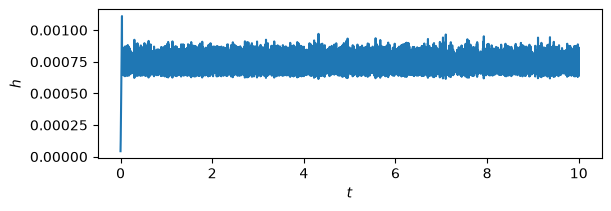

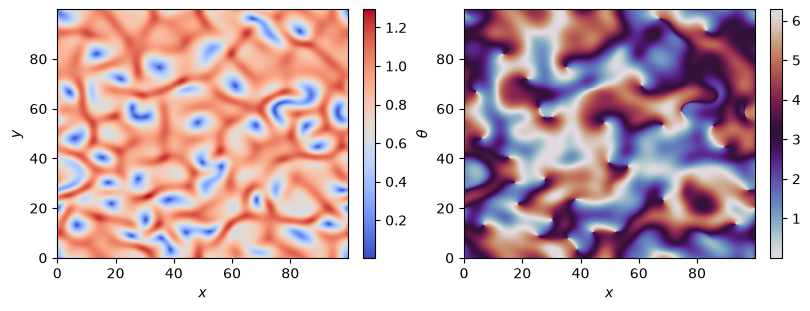

In [13]:
file=open(filebase+'.out')
print(file.readlines()[-1])
file.close()

ys=np.fromfile(filebase+'states.dat').reshape([-1]+[2]+Ns)
ts=np.fromfile(filebase+'times.dat')

fig = plt.figure(figsize=(6,2),layout='constrained')
plt.plot(ts[:-1],np.diff(ts))
plt.xlabel(r'$t$')
plt.ylabel(r'$h$')
plt.show()


fig = plt.figure(figsize=(8,3), layout='constrained')
ax = fig.add_subplot(1,2,1)

R=(ys[-1][0]**2+ys[-1][1]**2)**0.5

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='coolwarm')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
plt.colorbar()

ax = fig.add_subplot(1,2,2)

R=np.atan2(ys[-1][1],ys[-1][0])+np.pi

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='twilight')
ax.set_xlabel('$x$')
ax.set_ylabel(r'$\theta$')
plt.colorbar()

plt.show()


In [14]:
Ns=[1024,1024]
Ls=[100.0,100.0]

cmd='%s ./rdcu -t %f -d %f -N %i,%i -L %f,%f -S -n 2 -v -D1 %s'%(loadstr,T,dt,Ns[0],Ns[1],Ls[0],Ls[1],filebase)
print(cmd)
os.system(cmd)

module load cuda/12.9.1-binary && ./rdcu -t 10.000000 -d 0.100000 -N 1024,1024 -L 100.000000,100.000000 -S -n 2 -v -D1 data/2dcgle
Using coupling terms from file
u0'=1.000(u0)^1 + 1.000(u0_00)^1 + 1.000(u0_11)^1 + -2.000(u1_00)^1 + -2.000(u1_11)^1 + -1.000(u0)^3 + -1.000(u0)^1(u1)^2 + -0.800(u0)^2(u1)^1 + -0.800(u1)^3 + 0
u1'=1.000(u1)^1 + 1.000(u1_00)^1 + 1.000(u1_11)^1 + 2.000(u0_00)^1 + 2.000(u0_11)^1 + -1.000(u0)^2(u1)^1 + -1.000(u1)^3 + 0.800(u0)^3 + 0.800(u0)^1(u1)^2 + 0
Using random initial conditions
1.003	4.860e+01	-1.274e-01	0.035411	779	
runtime: 48.760208


0

runtime: 48.760208



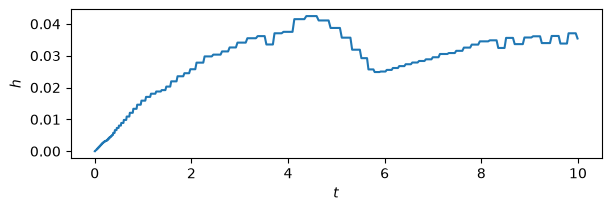

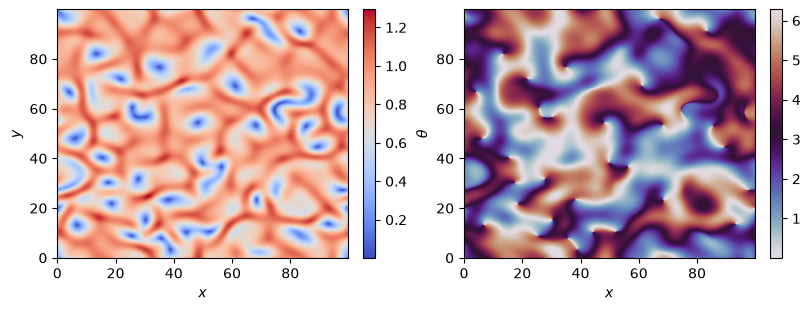

In [15]:
file=open(filebase+'.out')
print(file.readlines()[-1])
file.close()

ys=np.fromfile(filebase+'states.dat').reshape([-1]+[2]+Ns)
ts=np.fromfile(filebase+'times.dat')

fig = plt.figure(figsize=(6,2),layout='constrained')
plt.plot(ts[:-1],np.diff(ts))
plt.xlabel(r'$t$')
plt.ylabel(r'$h$')
plt.show()


fig = plt.figure(figsize=(8,3), layout='constrained')
ax = fig.add_subplot(1,2,1)

R=(ys[-1][0]**2+ys[-1][1]**2)**0.5

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='coolwarm')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
plt.colorbar()

ax = fig.add_subplot(1,2,2)

R=np.atan2(ys[-1][1],ys[-1][0])+np.pi

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='twilight')
ax.set_xlabel('$x$')
ax.set_ylabel(r'$\theta$')
plt.colorbar()

plt.show()

For both integration methods, we can reload saved final states in FILEBASEfs.dat with the -R flag to continue

In [16]:
cmd='%s./rdcu -t %f -d %f -N %i,%i -L %f,%f -R -S -n 2 -v -D1 %s'%(loadstr,2*T,dt,Ns[0],Ns[1],Ls[0],Ls[1],filebase)
print(cmd)
os.system(cmd)

module load cuda/12.9.1-binary &&./rdcu -t 20.000000 -d 0.100000 -N 1024,1024 -L 100.000000,100.000000 -R -S -n 2 -v -D1 data/2dcgle
Using coupling terms from file
u0'=1.000(u0)^1 + 1.000(u0_00)^1 + 1.000(u0_11)^1 + -2.000(u1_00)^1 + -2.000(u1_11)^1 + -1.000(u0)^3 + -1.000(u0)^1(u1)^2 + -0.800(u0)^2(u1)^1 + -0.800(u1)^3 + 0
u1'=1.000(u1)^1 + 1.000(u1_00)^1 + 1.000(u1_11)^1 + 2.000(u0_00)^1 + 2.000(u0_11)^1 + -1.000(u0)^2(u1)^1 + -1.000(u1)^3 + 0.800(u0)^3 + 0.800(u0)^1(u1)^2 + 0
Reloading final conditions from file
Restarting at t=10.026377 with h=0.035411
1.002	2.702e+01	-6.126e-02	0.035654	273	
runtime: 27.208961


0

runtime: 27.208961



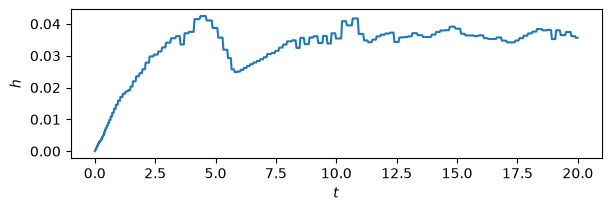

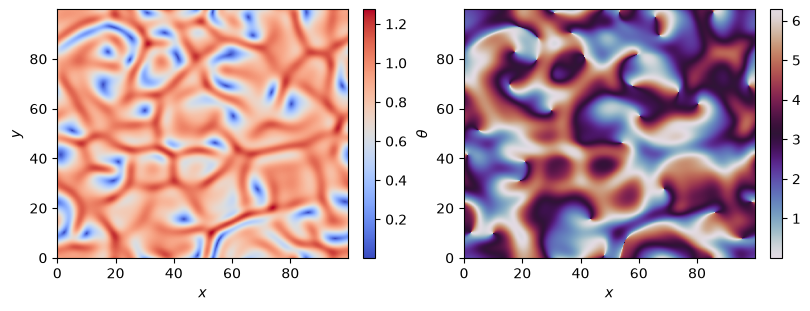

In [17]:
file=open(filebase+'.out')
print(file.readlines()[-1])
file.close()

ys=np.fromfile(filebase+'states.dat').reshape([-1]+[2]+Ns)
ts=np.fromfile(filebase+'times.dat')

fig = plt.figure(figsize=(6,2),layout='constrained')
plt.plot(ts[:-1],np.diff(ts))
plt.xlabel(r'$t$')
plt.ylabel(r'$h$')
plt.show()


fig = plt.figure(figsize=(8,3), layout='constrained')
ax = fig.add_subplot(1,2,1)

R=(ys[-1][0]**2+ys[-1][1]**2)**0.5

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='coolwarm')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
plt.colorbar()

ax = fig.add_subplot(1,2,2)

R=np.atan2(ys[-1][1],ys[-1][0])+np.pi

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='twilight')
ax.set_xlabel('$x$')
ax.set_ylabel(r'$\theta$')
plt.colorbar()

plt.show()


1D CGLE. Change parameters for an intermittency example.

In [18]:
Ns=[8192]
N=Ns[0]
Ls=[200.0] 
T=100

filebase='data/1dcgle'

b=0.1
c=2.0
couplings=['1.0,0,0,1', '1.0,0,4,1', '-%f,0,5,1'%(b),  \
           '-1.0,0,0,3', '-1.0,0,0,1,1,2', '1.0,1,1,1', \
           '1.0,1,5,1', '%f,1,4,1'%(b), \
           '-1.0,1,0,2,1,1', '-1.0,1,1,3', '%f,1,0,3'%(c), '%f,1,0,1,1,2'%(c), \
           '-%f,0,0,2,1,1'%(c),'-%f,0,1,3'%(c)]

file=open('%scoupling.dat'%(filebase),'w')
for line in couplings:
    print(line,file=file)
file.close()

cmd='%s ./rdcu -t %f -d %f -N %i -L %f -n 2 -v -D1 -S %s'%(loadstr,T,dt,Ns[0],Ls[0],filebase)
print(cmd)
os.system(cmd)

module load cuda/12.9.1-binary && ./rdcu -t 100.000000 -d 0.100000 -N 8192 -L 200.000000 -n 2 -v -D1 -S data/1dcgle
Using coupling terms from file
u0'=1.000(u0)^1 + 1.000(u0_00)^1 + -0.100(u1_00)^1 + -1.000(u0)^3 + -1.000(u0)^1(u1)^2 + -2.000(u0)^2(u1)^1 + -2.000(u1)^3 + 0
u1'=1.000(u1)^1 + 1.000(u1_00)^1 + 0.100(u0_00)^1 + -1.000(u0)^2(u1)^1 + -1.000(u1)^3 + 2.000(u0)^3 + 2.000(u0)^1(u1)^2 + 0
Using random initial conditions
1.000	7.370e+00	-8.993e-04	0.028828	3737	
runtime: 7.372056


0

runtime: 7.372056



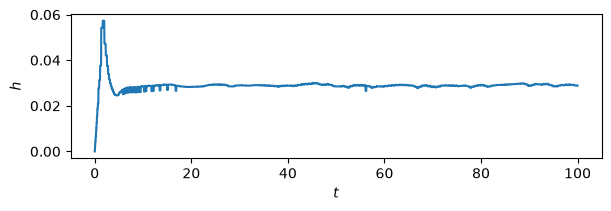

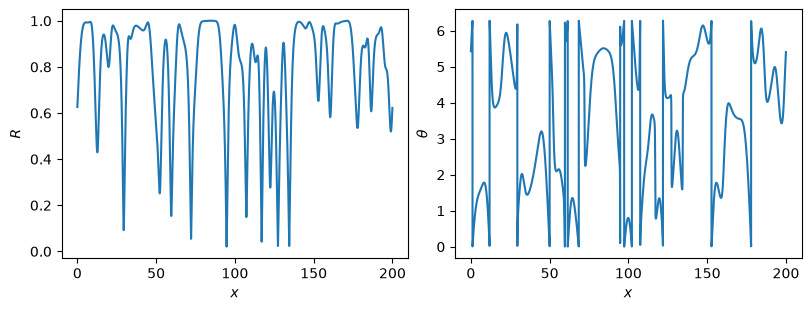

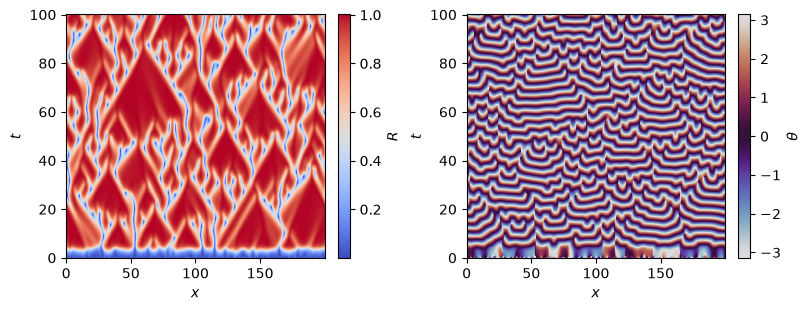

In [19]:
file=open(filebase+'.out')
print(file.readlines()[-1])
file.close()

ys=np.fromfile(filebase+'states.dat').reshape([-1]+[2]+Ns)
ts=np.fromfile(filebase+'times.dat')

fig = plt.figure(figsize=(6,2),layout='constrained')
plt.plot(ts[:-1],np.diff(ts))
plt.xlabel(r'$t$')
plt.ylabel(r'$h$')
plt.show()


fig = plt.figure(figsize=(8,3), layout='constrained')
ax = fig.add_subplot(1,2,1)

R=(ys[-1][0]**2+ys[-1][1]**2)**0.5

plt.plot(np.arange(Ns[0])/Ns[0]*Ls[0], R)
ax.set_xlabel('$x$')
ax.set_ylabel('$R$')

ax = fig.add_subplot(1,2,2)

R=np.atan2(ys[-1][1],ys[-1][0])+np.pi

plt.plot(np.arange(Ns[0])/Ns[0]*Ls[0], R)
ax.set_xlabel('$x$')
ax.set_ylabel(r'$\theta$')

plt.show()

fig = plt.figure(figsize=(8,3), layout='constrained')
ax = fig.add_subplot(1,2,1)

R=(ys[:,0]**2+ys[:,1]**2)**0.5

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(ys.shape[0])*0.1, R,cmap='coolwarm')
plt.xlabel(r'$x$')
plt.ylabel(r'$t$')
plt.colorbar(label=r'$R$')

ax = fig.add_subplot(1,2,2)

R=np.atan2(ys[:,1],ys[:,0])

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(ys.shape[0])*0.1, R,cmap='twilight')
plt.xlabel(r'$x$')
plt.ylabel(r'$t$')
plt.colorbar(label=r'$\theta$')

plt.show()

3D CGLE. Make a fancy animation with defect lines. Do fixed timesteps for T0 initial time units first to initialize a random state, then run for T time units. Animate all outputs after T1 later.

In [5]:
Ns=np.array([64,64,64])
Ls=[100.0,100.0,100.0]
# b=0.5
# c=2.0
b=2.0
c=0.4
seed=100
filebase='data/3dcgle'
T0=0.1
dt0=1E-3

T=500
dt=0.1

T1=400
n0=int(T0/dt0)+int(T1/dt)
nt=int(T/dt)-int(T1/dt)

# Ns=np.array([128,128,128])
# Ls=[200.0,200.0,200.0]
# b=0.0
# c=1.5
# filebase='data/3dcgle_2'
# T0=0.1
# dt0=1E-3

# T=1500
# dt=1.0

# T1=500
# n0=int(T0/dt0)+int(T1/dt)
# nt=int(T/dt)-int(T1/dt)

couplings=['1.0,0,0,1', '1.0,0,8,1', '1.0,0,16,1', '1.0,0,24,1', '-%f,0,9,1'%(b), \
           '-%f,0,17,1'%(b), '-%f,0,25,1'%(b), '-1.0,0,0,3', '-1.0,0,0,1,1,2', '1.0,1,1,1', \
           '1.0,1,9,1', '1.0,1,17,1', '1.0,1,25,1', '%f,1,8,1'%(b),'%f,1,16,1'%(b), '%f,1,24,1'%(b), \
           '-1.0,1,0,2,1,1', '-1.0,1,1,3', '%f,1,0,3'%(c), '%f,1,0,1,1,2'%(c), \
           '-%f,0,0,2,1,1'%(c),'-%f,0,1,3'%(c)]

file=open('%scoupling.dat'%(filebase),'w')
for line in couplings:
    print(line,file=file)
file.close()

In [3]:
cmd='%s ./rdcu -s 1 -t %f -d %f -N %i,%i,%i -L %f,%f,%f -s %i -n 2 -D1 -Fv %s'%(loadstr,T0,dt0,Ns[0],Ns[1],Ns[2],Ls[0],Ls[1],Ls[2],seed,filebase)
print(cmd)
os.system(cmd)
cmd='%s ./rdcu -s 1 -t %f -d %f -N %i,%i,%i -L %f,%f,%f -s %i -n 2 -D1 -Rv  %s'%(loadstr,T,dt,Ns[0],Ns[1],Ns[2],Ls[0],Ls[1],Ls[2],seed,filebase)
print(cmd)
os.system(cmd)

module load cuda/12.9.1-binary && ./rdcu -s 1 -t 0.100000 -d 0.001000 -N 128,128,128 -L 50.000000,50.000000,50.000000 -s 100 -n 2 -D1 -Fv data/3dcgle
Using coupling terms from file
u0'=1.000(u0)^1 + 1.000(u0_00)^1 + 1.000(u0_11)^1 + 1.000(u0_22)^1 + -0.500(u1_00)^1 + -0.500(u1_11)^1 + -0.500(u1_22)^1 + -1.000(u0)^3 + -1.000(u0)^1(u1)^2 + -2.000(u0)^2(u1)^1 + -2.000(u1)^3 + 0
u1'=1.000(u1)^1 + 1.000(u1_00)^1 + 1.000(u1_11)^1 + 1.000(u1_22)^1 + 0.500(u0_00)^1 + 0.500(u0_11)^1 + 0.500(u0_22)^1 + -1.000(u0)^2(u1)^1 + -1.000(u1)^3 + 2.000(u0)^3 + 2.000(u0)^1(u1)^2 + 0
Using random initial conditions
1.000	1.251e+02	-8.248e-14	0.001000	100	
runtime: 125.376624
module load cuda/12.9.1-binary && ./rdcu -s 1 -t 500.000000 -d 0.100000 -N 128,128,128 -L 50.000000,50.000000,50.000000 -s 100 -n 2 -D1 -Rv  data/3dcgle
Using coupling terms from file
u0'=1.000(u0)^1 + 1.000(u0_00)^1 + 1.000(u0_11)^1 + 1.000(u0_22)^1 + -0.500(u1_00)^1 + -0.500(u1_11)^1 + -0.500(u1_22)^1 + -1.000(u0)^3 + -1.000(u0)^1(u1

0

Find the lines of defects by finding the connected components in the graph of neighboring cells with nonzero wilson loops on a face

In [6]:
def wloop(th, axis1=0, axis2=1):
    dth1=np.mod(np.roll(th,-1,axis=axis1)-th+np.pi,2*np.pi)-np.pi
    dth2=np.mod(np.roll(np.roll(th,-1,axis=axis1),-1,axis=axis2)-np.roll(th,-1,axis=axis1)+np.pi,2*np.pi)-np.pi
    dth3=np.mod(np.roll(th,-1,axis=axis2)-np.roll(np.roll(th,-1,axis=axis1),-1,axis=axis2)+np.pi,2*np.pi)-np.pi
    dth4=np.mod(th-np.roll(th,-1,axis=axis2)+np.pi,2*np.pi)-np.pi
    return np.round((dth1+dth2+dth3+dth4)/(2*np.pi))

    
def findlines(th):
    #each cube sharing a face with a line passing through it
    lines01=coo_array(wloop(th, axis1=0, axis2=1)).coords
    lines12=coo_array(wloop(th, axis1=1, axis2=2)).coords
    lines20=coo_array(wloop(th, axis1=2, axis2=0)).coords
    lines012=lines01+np.array([0,0,-1])[:,np.newaxis]
    lines012[2]=np.mod(lines012[2]+Ns[2],Ns[2])
    lines120=lines12+np.array([-1,0,0])[:,np.newaxis]
    lines120[0]=np.mod(lines120[0]+Ns[0],Ns[0])
    lines201=lines20+np.array([0,-1,0])[:,np.newaxis]
    lines201[1]=np.mod(lines201[1]+Ns[1],Ns[1])
    
    lines=np.concatenate([lines01,lines012,lines12,lines120,lines20,lines201],axis=1)
    raveled=np.apply_along_axis(lambda row: np.ravel_multi_index(row,Ns), axis=0, arr=lines)
    lines=np.array(np.unravel_index(np.unique(raveled),shape=Ns))
    
    diffs=(lines[:,:,np.newaxis]-lines[:,np.newaxis,:])
    for axis in range(3):
        diffs[axis]=np.mod(diffs[axis]+Ns[axis]//2,Ns[axis])-Ns[axis]//2
        
    adj=np.linalg.norm(diffs,ord=1,axis=0).astype(int)
    adj=np.where(adj<=1,adj,0)
    G=nx.from_numpy_array(adj)
    lines=[(lines[:,list(G.subgraph(c).edges)]).transpose((1,2,0))*Ls/(Ns-1) for c in nx.connected_components(G)]
    return lines

In [7]:
def savelines(n):
    file=open(filebase+'states.dat','rb')
    file.seek((n0+n)*8*2*Ns[0]*Ns[1]*Ns[2])
    dat=file.read(8*2*Ns[0]*Ns[1]*Ns[2])
    ys=np.array(struct.unpack('%id'%(2*Ns[0]*Ns[1]*Ns[2]),dat)).reshape([2]+Ns.tolist())
    file.close()
    th=np.atan2(ys[1],ys[0])+np.pi
    return findlines(th)
    
start=timeit.default_timer()
pool=Pool(16,maxtasksperchild=1) 
lines=pool.map(savelines, range(nt))
pool.close()
stop=timeit.default_timer()
print("lines time: ", stop-start)

lines time:  108.9186538150534


Correlate the lines across timesteps and track their ancestry, and assign each line a color id based on its longest parent

In [8]:
def correlate(n):
    diffs=np.zeros((len(lines[n]),len(lines[n-1])),dtype=int)
    for i in range(len(lines[n])):
        for j in range(len(lines[n-1])):
            diffs[i,j]=np.round(np.min(np.linalg.norm(lines[n][i][:,np.newaxis]/(Ls/(Ns-1))-lines[n-1][j][np.newaxis,:]/(Ls/(Ns-1)),ord=1,axis=-1)))
    return diffs
    
start=timeit.default_timer()
pool=Pool(16,maxtasksperchild=1) 
results=pool.map(correlate, range(1,nt))
pool.close()
stop=timeit.default_timer()
print("correlate time: ", stop-start)

correlate time:  54.22431747079827


In [9]:
lengths=[]
for line in lines:
    length=[]
    for l in line:
        length=length+[len(l)]
    lengths=lengths+[length]

th=5 #threshold distance to determine if lines at different timesteps are related
parentinds=[np.arange(len(lines[0])).reshape((-1,1)).tolist()]
for n in range(nt-1):
    ps=[[]]*results[n].shape[0]
    for i in range(results[n].shape[0]):
        mdist=np.min(results[n][i])
        if mdist<=th:
            ps[i]=np.where(results[n][i]==mdist)[0].tolist()
    parentinds=parentinds+[ps] 
    
siblinginds=[]
for pinds in parentinds:
    sinds=[]
    pstrs=["_".join(np.array(p,dtype=str)) for p in pinds]

    for pstr in pstrs:
        s=np.where(pstr==np.array(pstrs))[0]
        sinds=sinds+[s.tolist()]
    siblinginds=siblinginds+[sinds]


#find the id and color of the lines
#if one or more lines spawn children, the longest child inherits the longest parent's color
ids=[np.arange(len(lines[0]))]
cids=[np.arange(len(lines[0]))]
nextid=len(lines[0])
nextcid=len(lines[0])
edges=[]
for n in np.arange(1,nt):
    i=np.zeros(len(parentinds[n]),dtype=int)
    ci=np.zeros(len(parentinds[n]),dtype=int)
    for m in range(len(parentinds[n])):
        if len(parentinds[n][m])==1 and len(siblinginds[n][m])==1:
            i[m]=ids[n-1][parentinds[n][m][0]]
            ci[m]=cids[n-1][parentinds[n][m][0]]
        else:
            i[m]=nextid
            nextid=nextid+1
            if len(parentinds[n][m])==0:
                ci[m]=nextcid
                nextcid=nextcid+1
            else:
                longestparentind=np.argmax(np.array(lengths[n-1])[parentinds[n][m]])
                longestsiblingind=np.argmax(np.array(lengths[n])[siblinginds[n][m]])
                if m==siblinginds[n][m][longestsiblingind]:
                    ci[m]=cids[n-1][parentinds[n][m][longestparentind]]
                else:
                    ci[m]=nextcid
                    nextcid=nextcid+1
                
            for pind in parentinds[n][m]:
                edges=edges+[[ids[n-1][pind],i[m]]]
    ids=ids+[np.array(i)]
    cids=cids+[np.array(ci)]

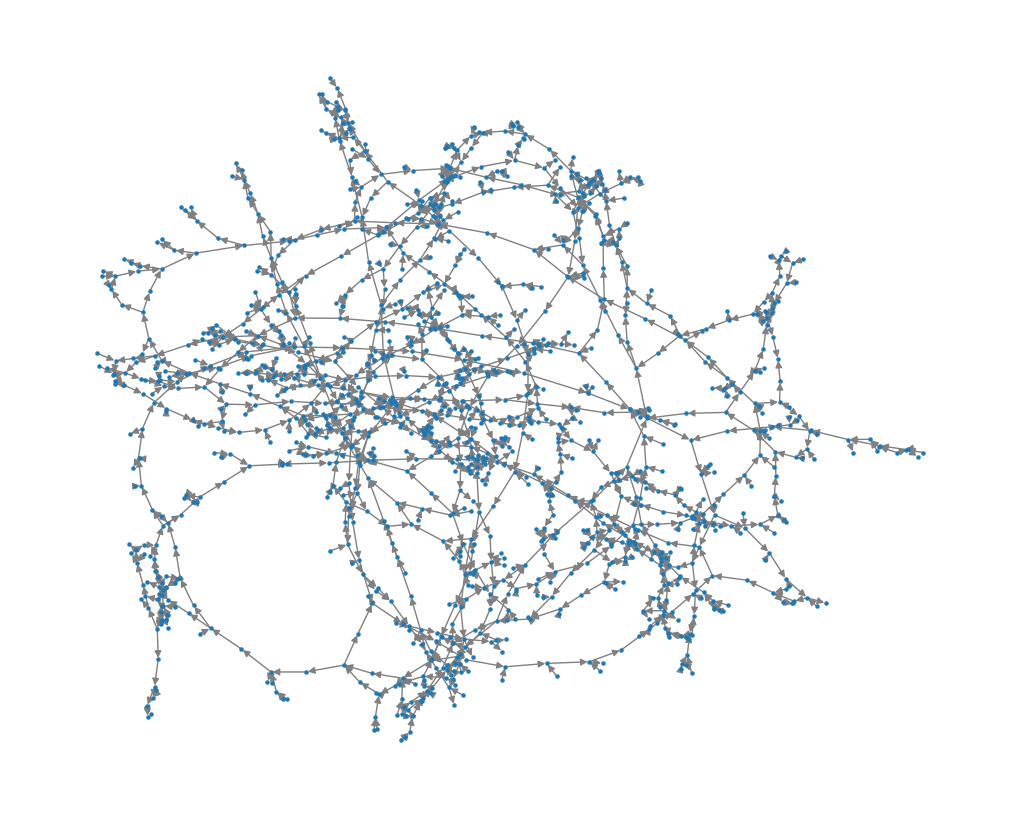

In [10]:
G=nx.DiGraph(edges)
plt.figure(figsize=(10, 8))
nx.draw(G,node_size=5,edge_color='gray')
plt.show()

plot the line ancestry as a directed acyclic graph

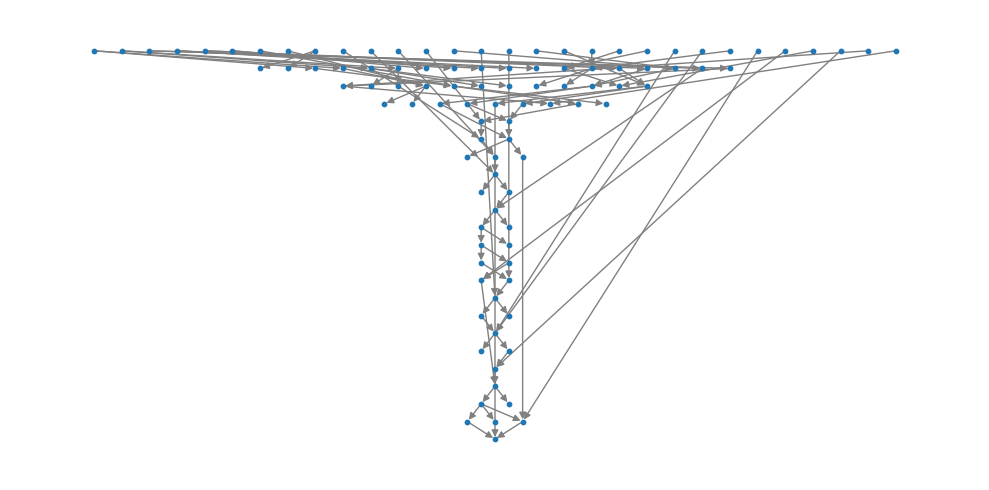

In [15]:
G=nx.DiGraph(edges[:100])

for layer_idx, nodes in enumerate(nx.topological_generations(G)):
    for node in nodes:
        G.nodes[node]["layer"] = layer_idx
pos = nx.multipartite_layout(G, subset_key="layer", align='horizontal')
for key in pos.keys():
    oldval=pos[key]
    newval=np.array([oldval[0],-oldval[1]])
    pos[key]=newval
plt.figure(figsize=(10, 5))
nx.draw_networkx(G,pos=pos,with_labels=False,edge_color='gray',node_size=10)

plt.axis("off")
plt.tight_layout()
plt.show()

plot the lines

In [16]:
def plotlines(lines, ids, ax):
    for i in range(len(lines)):
        c=colors[np.mod(ids[i],len(colors))]
        for line in lines[i]:
            if np.linalg.norm(line[0]-line[1],ord=np.inf)<np.min(Ls)/2:
                alpha=0.25*np.linalg.norm(([0,Ls[1],0]-line[0])/Ls,ord=np.inf)
                ax.plot(*line.T,lw=1.5, marker=None, c=c, alpha=alpha)
            else:
                if (line[0][0]==0 or line[0][1]==Ls[1] or line[0][2]==0) and not (line[1][0]==0 or line[1][1]==Ls[1] or line[1][2]==0):
                    ax.scatter(*line[0],s=10,color=c,alpha=0.25)
                if (line[0][0]==Ls[0] or line[0][1]==0 or line[0][2]==Ls[2]) and not (line[1][0]==Ls[0] or line[1][1]==0 or line[1][2]==Ls[2]):
                    ax.scatter(*line[0],s=10,color=c,alpha=1.0)
                if (line[1][0]==0 or line[1][1]==Ls[1] or line[1][2]==0) and not (line[0][0]==0 or line[0][1]==Ls[1] or line[0][2]==0):
                    ax.scatter(*line[1],s=10,color=c,alpha=0.25)
                if (line[1][0]==Ls[0] or line[1][1]==0 or line[1][2]==Ls[2]) and not (line[0][0]==Ls[0] or line[0][1]==0 or line[0][2]==Ls[2]):
                    ax.scatter(*line[1],s=10,color=c,alpha=1.0)
    
    ax.plot([Ls[0],Ls[0]],[0,0],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,Ls[0]],[0,0],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([Ls[0],Ls[0]],[0,Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,Ls[0]],[0,0],[0,0], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([Ls[0],Ls[0]],[0,Ls[1]],[0,0], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,0],[0,0],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([Ls[0],Ls[0]],[Ls[1],Ls[1]],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,Ls[0]],[Ls[1],Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,0],[0,Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    
    ax.set_xlim(0,Ls[0])
    ax.set_ylim(0,Ls[1])
    ax.set_zlim(0,Ls[1])
    
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.set_zlabel('$z$')

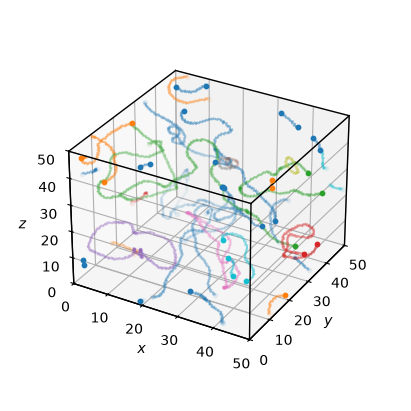

4.329083282966167


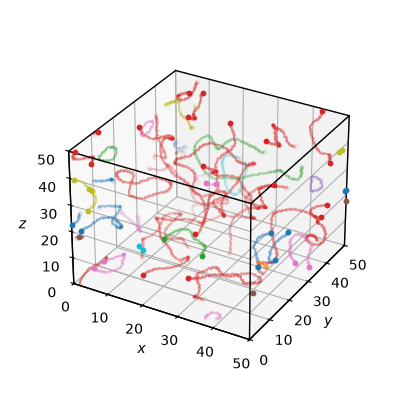

3.8611639288719743


In [17]:
def makeplot(n,show=False,save=True):
    if save and os.path.exists(filebase+'animation3/%04d.png'%(n)):
        return
    file=open(filebase+'states.dat','rb')
    file.seek((n0+n)*8*2*Ns[0]*Ns[1]*Ns[2])
    dat=file.read(8*2*Ns[0]*Ns[1]*Ns[2])
    ys=np.array(struct.unpack('%id'%(2*Ns[0]*Ns[1]*Ns[2]),dat)).reshape([2]+Ns.tolist())
    file.close()

    fig = plt.figure(figsize=(4,4), layout='constrained')
    
    ax = fig.add_subplot(1,1,1, projection='3d')
    tmp_planes = ax.zaxis._PLANES
    ax.zaxis._PLANES = (tmp_planes[2], tmp_planes[3], tmp_planes[0], tmp_planes[1], tmp_planes[4], tmp_planes[5])
    plotlines(lines[n], cids[n], ax)
    ax.set_box_aspect(aspect=None, zoom=0.8) 

    if save:
        plt.savefig(filebase+'animation3/%04d.png'%(n),bbox_inches="tight", pad_inches=0.1)
    if show:
        plt.show()
    plt.close(fig)

start=timeit.default_timer()
makeplot(0,show=True,save=False)
stop=timeit.default_timer()
print(stop-start)

start=timeit.default_timer()
makeplot(nt-1,show=True,save=False)
stop=timeit.default_timer()
print(stop-start)

plot the lines alongside the faces of the fields

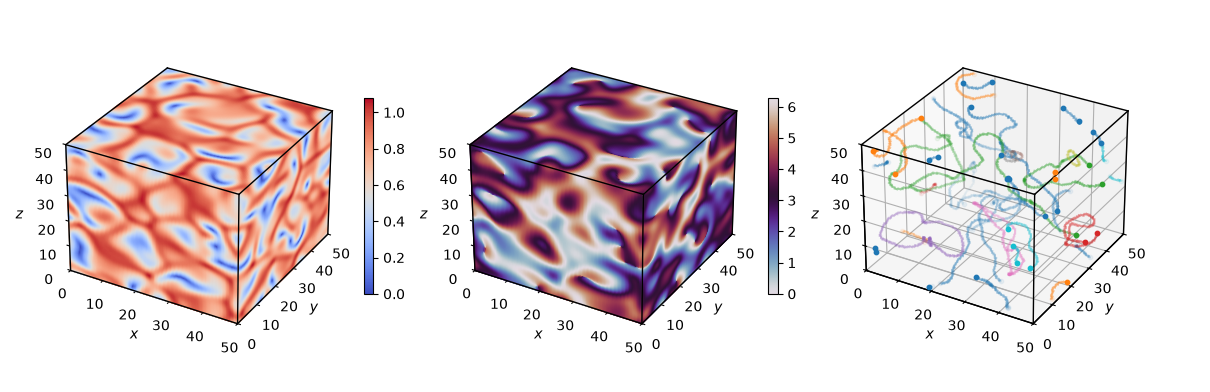

7.644206000957638


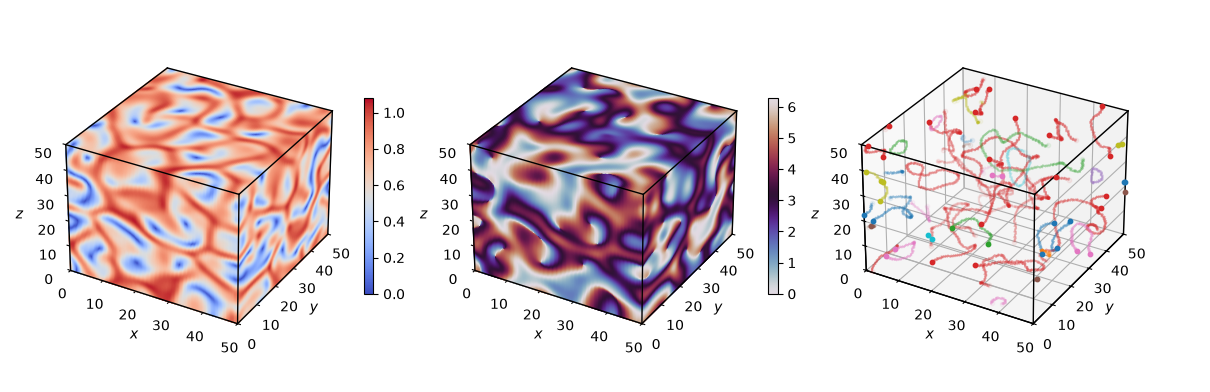

8.072693777037784


In [18]:
def plotfaces(R, ax, cmap):
    Rmax=np.max(R)
    Y,X=np.meshgrid(np.arange(Ns[0])/Ns[0]*Ls[0],np.arange(Ns[1])/Ns[1]*Ls[1])
    Z=Ls[2]*np.ones(X.shape)
    C=cmap(R[:,:,-1]/Rmax)
    ax.plot_surface(X,Y,Z,rstride=1, cstride=1, facecolors=C, shade=False)
    
    X,Z=np.meshgrid(np.arange(Ns[0])/Ns[0]*Ls[0],np.arange(Ns[2])/Ns[2]*Ls[2])
    Y=0*np.ones(X.shape)
    C=cmap(R[:,0,:].T/Rmax)
    ax.plot_surface(X,Y,Z,rstride=1, cstride=1, facecolors=C, shade=False)
    
    Z,Y=np.meshgrid(np.arange(Ns[1])/Ns[1]*Ls[1],np.arange(Ns[2])/Ns[2]*Ls[2])
    X=Ls[0]*np.ones(X.shape)
    C=cmap(R[-1,:,:]/Rmax)
    ax.plot_surface(X,Y,Z,rstride=1, cstride=1, facecolors=C, shade=False)
    
    ax.plot([Ls[0],Ls[0]],[0,0],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,Ls[0]],[0,0],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([Ls[0],Ls[0]],[0,Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,Ls[0]],[0,0],[0,0], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([Ls[0],Ls[0]],[0,Ls[1]],[0,0], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,0],[0,0],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([Ls[0],Ls[0]],[Ls[1],Ls[1]],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,Ls[0]],[Ls[1],Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,0],[0,Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    
    ax.set_xlim(0,Ls[0])
    ax.set_ylim(0,Ls[1])
    ax.set_zlim(0,Ls[2])
    
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.set_zlabel('$z$')
    

def makeplot2(n,show=False,save=True):
    if save and os.path.exists(filebase+'animation/%04d.png'%(n)):
        return
    file=open(filebase+'states.dat','rb')
    file.seek((n0+n)*8*2*Ns[0]*Ns[1]*Ns[2])
    dat=file.read(8*2*Ns[0]*Ns[1]*Ns[2])
    ys=np.array(struct.unpack('%id'%(2*Ns[0]*Ns[1]*Ns[2]),dat)).reshape([2]+Ns.tolist())
    file.close()

    fig = plt.figure(figsize=(12,4), layout='constrained')
    
    ax = fig.add_subplot(1,3,1, projection='3d')
    tmp_planes = ax.zaxis._PLANES
    ax.zaxis._PLANES = (tmp_planes[2], tmp_planes[3], tmp_planes[0], tmp_planes[1], tmp_planes[4], tmp_planes[5])
    R=(ys[0]**2+ys[1]**2)**0.5
    Rmax=np.max(R)
    plotfaces(R, ax, plt.get_cmap('coolwarm'))
    fig.colorbar(ScalarMappable(norm=Normalize(vmin=0, vmax=Rmax), cmap=plt.get_cmap('coolwarm')),ax=ax,location='right', shrink=0.5, pad=-0.05)
    ax.set_box_aspect(aspect=None, zoom=0.8) 

    ax = fig.add_subplot(1,3,2, projection='3d')
    tmp_planes = ax.zaxis._PLANES
    ax.zaxis._PLANES = (tmp_planes[2], tmp_planes[3], tmp_planes[0], tmp_planes[1], tmp_planes[4], tmp_planes[5])
    th=np.atan2(ys[1],ys[0])+np.pi
    thmax=2*np.pi
    plotfaces(th, ax, plt.get_cmap('twilight'))
    fig.colorbar(ScalarMappable(norm=Normalize(vmin=0, vmax=thmax), cmap=plt.get_cmap('twilight')),ax=ax,location='right', shrink=0.5, pad=-0.05)
    ax.set_box_aspect(aspect=None, zoom=0.8) 

    ax = fig.add_subplot(1,3,3, projection='3d')
    tmp_planes = ax.zaxis._PLANES
    ax.zaxis._PLANES = (tmp_planes[2], tmp_planes[3], tmp_planes[0], tmp_planes[1], tmp_planes[4], tmp_planes[5])
    lines=findlines(th)
    plotlines(lines, cids[n], ax)
    #invisible colorbar to scale the size consistently
    cbar=fig.colorbar(ScalarMappable(norm=Normalize(vmin=0, vmax=1), cmap=plt.get_cmap('gist_rainbow')),ax=ax,location='right', shrink=0.5, pad=-0.05,alpha=0)
    for spine in cbar.ax.spines.values():
        spine.set_edgecolor('white')
    cbar.ax.tick_params(color='white', labelcolor='white')

    ax.set_box_aspect(aspect=None, zoom=0.8) 

    if save:
        plt.savefig(filebase+'animation/%04d.png'%(n),bbox_inches="tight", pad_inches=0.1)
    if show:
        plt.show()
    plt.close(fig)

start=timeit.default_timer()
makeplot2(0,show=True,save=False)
stop=timeit.default_timer()
print(stop-start)

start=timeit.default_timer()
makeplot2(nt-1,show=True,save=False)
stop=timeit.default_timer()
print(stop-start)

In [19]:
if not os.path.exists(filebase+'animation'):
    os.mkdir(filebase+'animation')
else:
    os.system('rm %sanimation/*.png'%(filebase))

print(nt)
start=timeit.default_timer()
pool=Pool(16,maxtasksperchild=1) 
pool.map(makeplot2, range(nt))
pool.close()
stop=timeit.default_timer()
print("plot time: ", stop-start)

os.system('ffmpeg -y -r 30 -i %sanimation/'%(filebase)+'%04d.png'+ ' -c:v h264 -vf "pad=ceil(iw/2)*2:ceil(ih/2)*2,format=yuv420p" %sanimation.mp4'%(filebase))
display(Video('%sanimation.mp4'%(filebase)))


1000
plot time:  668.3462409889325


ffmpeg version 8.0.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (GCC)
  configuration: --prefix=/nfs/home/znicolao/.conda/envs/my_env --cc=/home/task_177679469598008/croot/ffmpeg_1776795393650/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/task_177679469598008/croot/ffmpeg_1776795393650/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/task_177679469598008/croot/ffmpeg_1776795393650/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/task_177679469598008/croot/ffmpeg_1776795393650/_build_env/bin/x86_64-conda-linux-gnu-ar --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --enable-libmp3lame --enable-libaom --enable-libsvtav1 --enable-libxml2 --enable-pic --enable-shared --enable-version3 --enable-zlib --enable-libvorbis --enable-libopus --enable-libwebp --enable-libshaderc --disable-ffplay --disable-static --disable-gpl --disable-doc 

size of the line trajectories in GB

In [26]:
np.sum([np.sum(l) for l in lengths])*2*3*8/2**30

np.float64(0.18905746936798096)